In [ ]:
# This is unspuervised learning algorithm which means we don't have labels 
# We don't have classifcation or regression
import numpy as np

# Kmeans class
class Kmeans():

    # Intialization
    def __init__(self, n_clusters=3, init_method='k-means++', eval_method='inertia', max_iters=100, tol=1e-4):
        # We have two types of intializations ---> Random and kmeans++
        # Ofcourse for better intialization we work with kmeans++
        # Here other paramerts default as API
        self.n_clusters = n_clusters
        self.init_method = init_method
        self.max_iters = max_iters
        self.tol = tol
        self.eval_method = eval_method

        # Intialize cetroids, labels and intertia as None because we haven't caculated them yet, we gonna need them later 
        self.cluster_centers_ = None
        self.labels_ = None
        self._intertia = None

    # Helper functions
    # The convention naming is close to scikit learn API
    # Intialize Centroid is the most important function and it is responsible of the bad or good clustering at the end as it is our start
    def _intialize_centeroids(self, X):

        # Get number of samples and features
        # Here X is numpy array so it was converted before called here
        n_samples, n_features = X.shape

        # First option is the academic intialization which is choosing all centroids as random
        if self.init_method == 'random':
            # Get random indices = the number of n_clusters
            # We make replace = False so no centroid duplicate again
            indices = np.random.choice(n_samples, self.n_clusters, replace=False)   
            # Filter data by selected indices 
            # Make it float for better convention
            return X[indices].astype(float)

        # Second option which is the dafault and the most correct option
        # First centroid selected as random
        centers = []
        first_centroid = np.random.randint(n_samples)
        centers.append(X[first_centroid])

        for centroid_intializer in range(1, self.n_clusters):
            # Calcualte the rest of the centroids
            # Step 1 --> D(x^2) O(n * n)
            # We loop on samples and each sample got the squqred euclidean distance between it and centroids stored in centroid list
            # We use sum because we have too many features in the centoid and the same in the sample
            # Then get min
            dists = np.array([min(np.sum((x - c)**2) for c in centers) for x in X])

            # Step 2 --> calcualte prob which is current min / sum of all currents (normalization)
            dists_sum = dists.sum()

            # Step 3 --> get all probabilities
            probs = dists / dists_sum

            # Step 4
            # As adcemic studies we should choose the farest point which is the highest probablity but it won't ribust against outliers
            # So we choose it random but putting in consideration the biggest probablity will be the MLE
            # We leave room for randomness
            next_indice = np.random.choice(n_samples, p= probs)
            next_centroid = X[next_indice]
            centers.append(next_centroid)

        # Return the centroids list
        return np.array(centers)    
    
    # Intertia method
    def _calculate_inertia(self, X):
        # First we filter with the related centroid
        assigned_centers = self.cluster_centers_[self.labels_]
        # Interia accumaltive formula
        return np.sum((X - assigned_centers)**2)

    def _calculate_silhouette(self, X):
    # Get samples number
        n_samples = X.shape[0]

        # Get all scores cause later we get the mean
        silhouette_vals = []
        
        # loop over all points and inside each iteration we have another loop for the closest cluster
        for i in range(n_samples):
            # Get a(i) so we work in the same cluster
            # Get the cluster of point first
            inside_cluster = X[self.labels_ == self.labels_[i]]
            if len(inside_cluster) > 1:
                # Make sure it is has more than two points
                # Inside cluster is the current cluster points
                a = np.mean(np.linalg.norm(inside_cluster - X[i], axis=1))
            else:
                # No points so no averga
                a = 0

            # intialize b to get min b at the end 
            b = np.inf
            # Loop over other cluster
            for label in range(self.n_clusters):
                # Get b(i) so we work with the closets cluster ignoring our current one
                if label == self.labels_[i]:
                    continue
                
                # Each time we calcualte b till we get the min one
                # Outside cluster is the outer current cluster points
                outside_cluster = X[self.labels_ == label]
                
                if len(outside_cluster)>0:
                    # Make sure it has point
                    current_b = np.mean(np.linalg.norm(outside_cluster - X[i], axis=1))
                    b = min(b, current_b)

            # Calcualte silhouette for current point and to be added later to the silhouette_vals
            # Add stability term to avoid zero devsion
            s = (b - a)  / (max(a, b) + 1e-9)       
            silhouette_vals.append(s)

        # Get the average of all score
        return np.mean(silhouette_vals)    
    
    # Fit
    def fit_predict(self, X):
        # We call it fit_predict as we not only calculate distances but also assign lables and it is logic to need assigning wether it is during train (fit_predict) or for new data coming (predict)
        # Convert x to array
        X = np.array(X)

        # Step 1 --> Choose K
        # Step 2 --> Intialization
        self.cluster_centers_ = self._intialize_centeroids(X)

        # Start iterations
        # we have global stopping criteria which is exceed the max_iters
        for iteration in range(self.max_iters):
            # Old centroids 
            # At first iteration the old version is the same version you gonna work with
            # Copy because we need later to compare if centroids move or no as self.clusters_centers_ will change later
            old_centroids = self.cluster_centers_.copy() 

            # Step 3  --> assign points to the closest centroid
            # We take the difference between points and clusters
            # we use np.newaxis as X is (m X n) and cluster_centers_ (k X n) so we can't devide all i need to devide each sample point from all centroids at once
            # So convert from (m x n) to (m x 1 x n) 3D matrix (samples, new axis to devide and n) to get (m, k, n_differ) so it is 3D
            differ = X[:, np.newaxis] - self.cluster_centers_
            # Here we choose axis = 2 to reach this diminsion of differ (n_differ) to get it is sum
            # So we have new array (m, n_differ) 2D matrix
            # Axis = 2 refers to old matrix and stored in new
            differ_sqr = np.sum(differ ** 2, axis=2)
            # Choose min distance so we go to axis = 1 to reach this diminsion of differ (n_differ) to get it is min
            # So we have new array (min_n_differ) 1D matrix
            self.labels_ = np.argmin(differ_sqr, axis=1)
            
            # Step 4
            # Update centroids
            # The sample idea is just getting mean of every cluster and will be synthetic point
            new_centroids = []

            # Loop over current clusters
            for cluster in range(self.n_clusters):
                # Get all current cluster points from labels_
                # Filter with 1D matrix (n_differ)
                mask = (self.labels_ == cluster)
                cluster_points = X[mask]

                # Make sure the cluster has points
                if len(cluster_points) > 0:
                    # Calculate the average 
                    # Get mean of array so we go to axis = 0 to reach this diminsion of min differ (min_n_differ) 
                    new_centers = cluster_points.mean(axis=0)
                    new_centroids.append(new_centers)
                else:
                    # Make sure we keep same number of centroids if empty cluster happens
                    new_centroids.append(old_centroids[cluster])

            # Assign new centroids to the new clusters
            self.cluster_centers_ = np.array(new_centroids)
            
            # Step 5 --> check convergence if it is less than tol
            # we need the space between old and current
            # Centroid shift is better than intertia shoft
            if np.linalg.norm(old_centroids - self.cluster_centers_) < self.tol:
                break
        
        # Evaluation step
        # Intertia case
        if self.eval_method == 'inertia':
            self.inertia_ = self._calculate_inertia(X)
            return self
        
        # Silhouette case
        elif self.eval_method == 'silhouette':
            self.silhouette_ = self._calculate_silhouette(X)
            return self

    # Predict
    def predict(self, X):
        # Here it is just geaometric prediction
        # Convert X to array
        X = np.array(X)
        # Choose the closest centroid so best cluster will be choosen
        distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
        return np.argmin(distances, axis=1) 

Calculating Elbow Method...


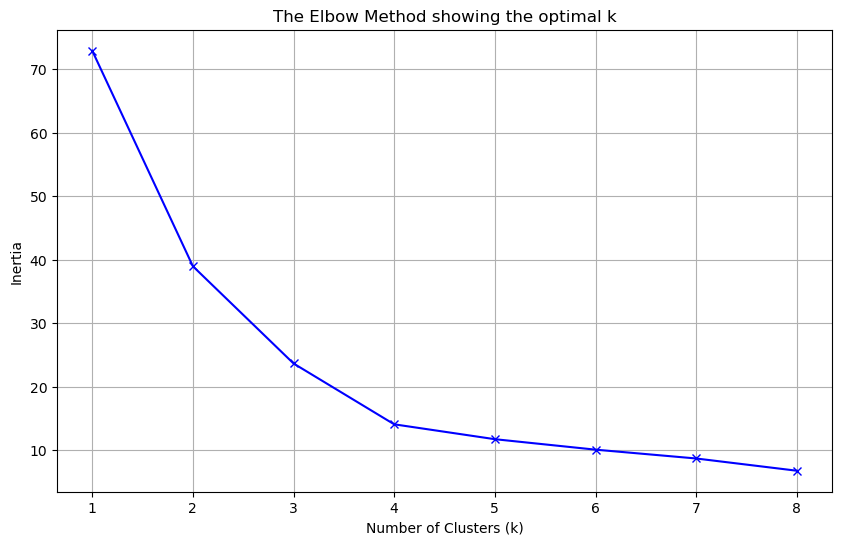

In [21]:
# For plotting purposes
import matplotlib.pyplot as plt

# Sample data
# Create number of rows and random x and y matrices
m = 100
# Use rand then multiple by 2 to make sure the samples values are between 0 and 2 this would make sure we simulate feature scaling
# Here we create 2 features
X1 = 2 * np.random.rand(m, 1)
X2 = 2 * np.random.rand(m, 1)
# Combine features to create X matrix
# We work only with x as y (label not exist)
X = np.column_stack((X1, X2))

# Test data with 2 rows
X_new = np.array([[1,2], [3,4], [4,3]])

# Get the best K using Elblow method
print("Calculating Elbow Method...")
# Collect all interia scores vs K
inertias = []
K = 9
for cluster_no in range(1, K):
    model = Kmeans(n_clusters=cluster_no, init_method='k-means++', eval_method='inertia')
    model.fit_predict(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, K), inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.grid(True)
plt.show()

In [ ]:
# k = 4 is the best
k = 4
# Apply default Kmeans with all possible parameters 
intializers = ['random', 'k-means++']
eval_metrics = ['inertia', 'silhouette']
print(f'Model: Kmeans')
for init in intializers:
    for eval in eval_metrics:
        # Get Kmeans Default object
        kmeans_model = Kmeans(n_clusters=k, init_method=init, eval_method=eval)
        kmeans_model.fit_predict(X)
        pred = kmeans_model.predict(X_new)
        print(f'Initializer: {init}')
        print(f'Evaluation: {eval}')
        print(f'Predictions for {X_new.tolist()}: {pred}')
        if eval == 'inertia':
            print(f'Evaluation score: {kmeans_model.inertia_:.2f}')
        elif eval == 'silhouette':
            print(f'Evaluation score: {kmeans_model.silhouette_:.2f}')
        print('-'*40)  

Model: Kmeans
Initializer: random
Evaluation: inertia
Predictions for [[1, 2], [3, 4], [4, 3]]: [2 0 0]
Evaluation score: 13.94
----------------------------------------
Initializer: random
Evaluation: silhouette
Predictions for [[1, 2], [3, 4], [4, 3]]: [2 3 3]
Evaluation score: 0.51
----------------------------------------
Initializer: k-means++
Evaluation: inertia
Predictions for [[1, 2], [3, 4], [4, 3]]: [0 0 0]
Evaluation score: 14.07
----------------------------------------
Initializer: k-means++
Evaluation: silhouette
Predictions for [[1, 2], [3, 4], [4, 3]]: [0 2 2]
Evaluation score: 0.51
----------------------------------------
